In [37]:
import numpy as np
from scipy.integrate import simpson
import matplotlib.pyplot as plt

/var/folders/k3/m30_3jg52wj6lqwh4vjvcstw0000gn/T/ipykernel_3115/4025620808.py:4: RuntimeWarning: invalid value encountered in divide
  dts = d_theta/(np.sqrt(np.cos(theta)-np.cos(theta_not)))
/var/folders/k3/m30_3jg52wj6lqwh4vjvcstw0000gn/T/ipykernel_3115/4025620808.py:4: RuntimeWarning: divide by zero encountered in divide
  dts = d_theta/(np.sqrt(np.cos(theta)-np.cos(theta_not)))


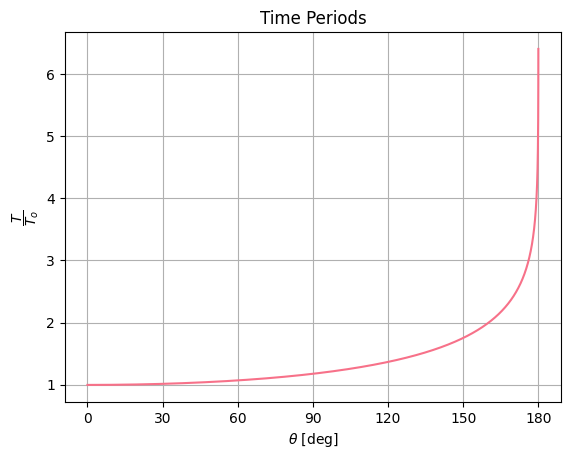

In [36]:
def timey_boi(theta_not):
    theta = np.linspace(0,theta_not,10001)
    d_theta = abs(theta[1]-theta[0])
    dts = d_theta/(np.sqrt(np.cos(theta)-np.cos(theta_not)))
    T = 4.0*sum(dts[:-1])
    return T

theta_nots = np.linspace(0,np.pi,10001)
time_periods = []

for theta_not in theta_nots:
    time_periods.append(timey_boi(theta_not))

time_periods = np.array(time_periods)

ax = plt.axes()
custom_ticks = np.arange(0,181,30)

ax.set_xticks(custom_ticks)

plt.plot(np.rad2deg(theta_nots),time_periods/(2*np.sqrt(2*9.806)))
plt.grid()
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$\dfrac{T}{T_o}$")
plt.title("Time Periods")
plt.savefig("Time_periods.svg")
plt.show()

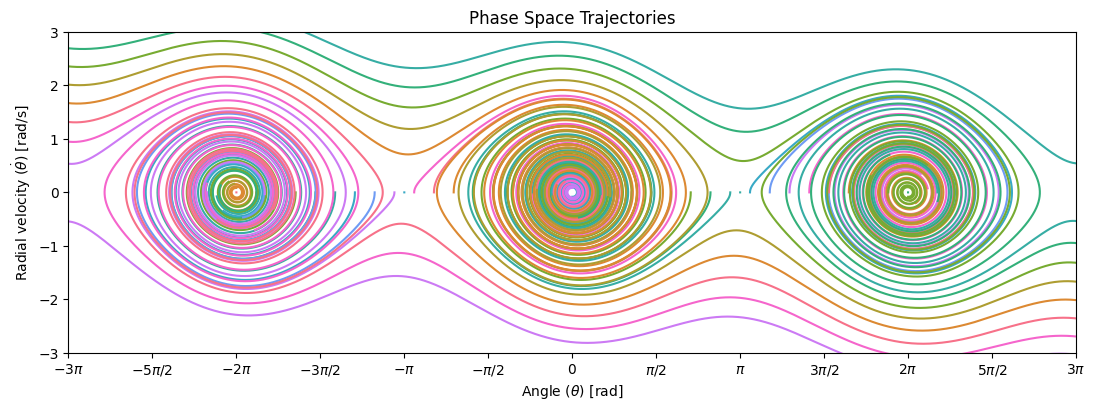

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

theta = np.linspace(-np.pi, np.pi, 10000)

def fo(time,theta,theta_dot):
    return theta_dot

def f1(time,theta,theta_dot):
    return -np.sin(theta) - theta_dot

# def f1(time,theta,theta_dot):
#     return -np.sin(theta)-np.sin(theta_dot)

def rk4(theta_o,theta_dot_o,dt,tf,to=0):
    n = int((tf-to)/dt) + 1
    theta_dot = []
    time = []
    theta = []
    for i in range(n):
        time.append(to)
        theta.append(theta_o)
        theta_dot.append(theta_dot_o)
        k1 = dt*fo(to, theta_o, theta_dot_o)
        k2 = dt*fo(to+(dt/2), theta_o+k1/2, theta_dot_o)
        k3 = dt*fo(to+(dt/2), theta_o+k2/2, theta_dot_o)
        k4 = dt*fo(to+dt, theta_o+k3, theta_dot_o)

        l1 = dt*f1(to, theta_o, theta_dot_o)
        l2 = dt*f1(to+(dt/2), theta_o, theta_dot_o+l1/2)
        l3 = dt*f1(to+(dt/2), theta_o, theta_dot_o+l2/2)
        l4 = dt*f1(to+dt, theta_o, theta_dot_o+l3)

        theta_o += (k1 + 2*k2 + 2*k3 + k4)/6
        theta_dot_o += (l1 + 2*l2 + 2*l3 + l4)/6

        to += dt
    return time,theta,theta_dot

theta_not = np.pi/2 - 1

thetas = np.linspace(-2*np.pi,2*np.pi,35)
theta_dots = np.linspace(-np.pi,np.pi,20)

sns.set_palette("husl",10)
fig = plt.figure(figsize=(13,5))
ax = plt.axes()

for i in thetas:
    t,theta,theta_dot = rk4(i,0,0.0001,30)
    plt.plot(theta,theta_dot)

t,theta,theta_dot = rk4(np.pi,0,0.0001,30)
plt.plot(theta,theta_dot)
t,theta,theta_dot = rk4(-np.pi,0,0.0001,30)
plt.plot(theta,theta_dot)
t,theta,theta_dot = rk4(-3*np.pi,0,0.0001,30)
plt.plot(theta,theta_dot)

for i in theta_dots[:9]:
    t,theta,theta_dot = rk4(10,i,0.0001,30)
    plt.plot(theta,theta_dot)

for i in theta_dots[-9:]:
    t,theta,theta_dot = rk4(-10,i,0.0001,30)
    plt.plot(theta,theta_dot)

plt.gca().set_aspect(20/20)

custom_ticks = [-3*np.pi, -(5*np.pi)/2, -2*np.pi, -(3*np.pi)/2, -np.pi, -np.pi/2, 0, np.pi/2, np.pi, (3*np.pi)/2, 2*np.pi, (5*np.pi)/2, 3*np.pi]
custom_tick_labels = [r'$-3\pi$', r'$-5\pi/2$', r'$-2\pi$', r'$-3\pi/2$', r'$-\pi$', r'$-\pi/2$', '$0$', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$', r'$5\pi/2$', r'$3\pi$']

ax.set_xticks(custom_ticks)
ax.set_xticklabels(custom_tick_labels)

plt.xlim(-3*np.pi,3*np.pi)
plt.ylim(-3,3)

plt.xlabel(r"Angle ($\theta$) [rad]")
plt.ylabel(r"Radial velocity ($\dot{\theta}$) [rad/s]")
plt.title("Phase Space Trajectories")
# plt.savefig("Phase_space_trajectory_3.svg")
plt.show()

Text(0.5, 1.0, '')

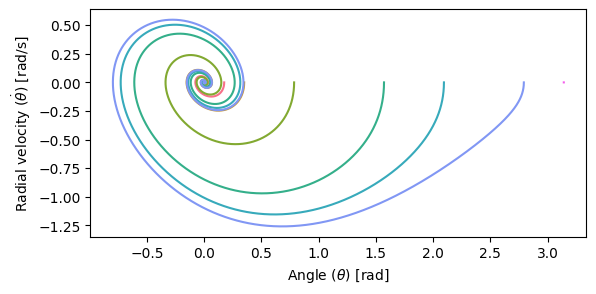

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def fo(time,theta,theta_dot):
    return theta_dot

def f1(time,theta,theta_dot):
    return -np.sin(theta) - 0.5*theta_dot

def rk4(theta_o,theta_dot_o,dt,tf,to=0):
    n = int((tf-to)/dt) + 1
    theta_dot = []
    time = []
    theta = []
    for i in range(n):
        time.append(to)
        theta.append(theta_o)
        theta_dot.append(theta_dot_o)
        k1 = dt*fo(to, theta_o, theta_dot_o)
        k2 = dt*fo(to+(dt/2), theta_o+k1/2, theta_dot_o)
        k3 = dt*fo(to+(dt/2), theta_o+k2/2, theta_dot_o)
        k4 = dt*fo(to+dt, theta_o+k3, theta_dot_o)

        l1 = dt*f1(to, theta_o, theta_dot_o)
        l2 = dt*f1(to+(dt/2), theta_o, theta_dot_o+l1/2)
        l3 = dt*f1(to+(dt/2), theta_o, theta_dot_o+l2/2)
        l4 = dt*f1(to+dt, theta_o, theta_dot_o+l3)

        theta_o += (k1 + 2*k2 + 2*k3 + k4)/6
        theta_dot_o += (l1 + 2*l2 + 2*l3 + l4)/6

        to += dt
    return time,theta,theta_dot


sns.set_palette("husl",7)

theta = np.linspace(-np.pi, np.pi, 10000)
thetas = np.deg2rad([10,20,45,90,120,160,180])
# print(thetas)

for i in thetas:
    t,theta,theta_dot = rk4(i,0,0.0001,50)
    plt.plot(theta,theta_dot)

plt.gca().set_aspect(10/10)
# plt.xlim(-4,4)
plt.xlabel(r"Angle ($\theta$) [rad]")
plt.ylabel(r"Radial velocity ($\dot{\theta}$) [rad/s]")
plt.title("")
# plt.savefig("Phase_space_given.svg")

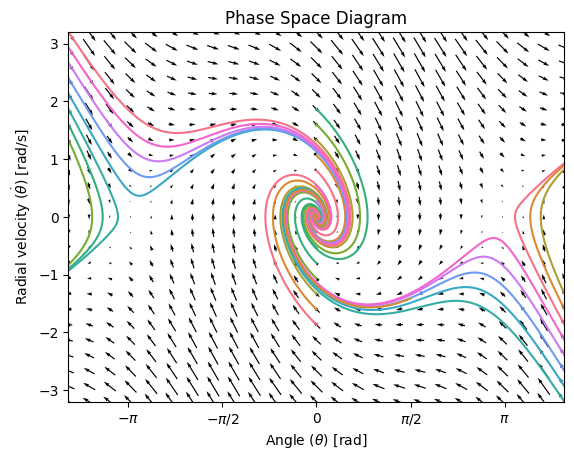

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def fo(time,theta,theta_dot):
    return theta_dot

def f1(time,theta,theta_dot):
    return -np.sin(theta) - 0.5*theta_dot

xlims = np.pi+1
ylims = 3.2

sns.set_palette("husl",10)

ax = plt.axes()

custom_ticks = [-(3*np.pi)/2, -np.pi, -np.pi/2, 0, np.pi/2, np.pi, (3*np.pi)/2]
custom_tick_labels = [r'$-3\pi/2$', r'$-\pi$', r'$-\pi/2$', '$0$', r'$\pi/2$', r'$\pi$', r'$3\pi/2$']

ax.set_xticks(custom_ticks)
ax.set_xticklabels(custom_tick_labels)

thetas = np.linspace(-xlims,xlims,25)
theta_dots = np.linspace(-ylims,ylims,25)

Theta, Theta_dot = np.meshgrid(thetas,theta_dots)

vect_x = np.zeros_like(Theta)
vect_y = np.zeros_like(Theta_dot)

dt = 0.01

for i in range(len(Theta)):
    for j in range(len(Theta[0])):
        vect_x[i][j] = fo(0,Theta[i][j],Theta_dot[i][j])
        vect_y[i][j] = f1(0,Theta[i][j],Theta_dot[i][j])
        norm = np.sqrt(vect_x**2+vect_y**2)
        # vect_x /= norm
        # vect_y /= norm


for i in theta_dots[5:-5]:
    t,theta,theta_dot = rk4(0,i,0.0001,30)
    plt.plot(theta,theta_dot)

for i in theta_dots[:8]:
    t,theta,theta_dot = rk4(xlims,i,0.0001,30)
    plt.plot(theta,theta_dot)

for i in theta_dots[-8:]:
    t,theta,theta_dot = rk4(-xlims,i,0.0001,30)
    plt.plot(theta,theta_dot)

# t,theta,theta_dot = rk4(-np.pi,0,0.0001,30)
# plt.plot(theta,theta_dot)
# plt.plot(np.array(theta)+2*np.pi,theta_dot)
# plt.plot(np.array(theta)-2*np.pi,theta_dot)

t,theta,theta_dot = rk4(np.pi/2,-1.414,0.00001,30)
plt.plot(theta,theta_dot)

t,theta,theta_dot = rk4(-3*np.pi/2,-1.414,0.00001,30)
plt.plot(theta,theta_dot)

t,theta,theta_dot = rk4(3*np.pi/2,-1.414,0.00001,30)
plt.plot(theta,theta_dot)

plt.quiver(Theta,Theta_dot,vect_x,vect_y,pivot="mid")

plt.xlim(-xlims,xlims)
plt.ylim(-ylims,ylims)
plt.xlabel(r"Angle ($\theta$) [rad]")
plt.ylabel(r"Radial velocity ($\dot{\theta}$) [rad/s]")
plt.title("Phase Space Diagram")
# plt.savefig("Phase_space_diag_3.svg")
plt.show()